# Custo fixo do milho 2ª safra — cenário "Custo Operacional (CONAB)"

Este notebook estende a seção 6 do `09_analise_custo_modelos.ipynb` com um **4º cenário de custo
fixo**, motivado por uma dúvida concreta sobre a fonte de custo: o `custo_fixo_real` usado no `09`
vem do SEAB/DERAL (`nhistorico_94.xls`, aba `milho_saf`), que só publica **Custo Variável** e
**Custo Total** por safra — sem separar quanto desse "fixo" é desembolso real (depreciação de
máquina, mão de obra permanente) e quanto é **custo imputado** de capital/terra (Renda de
Fatores), que não é dinheiro que sai do bolso.

**A pergunta que motivou esta análise**: o milho safrinha sucede a soja na mesma área, no mesmo
ano-agrícola. O `09` já testa isso com 2 cenários de rateio do custo fixo inteiro (seções 6.1/6.2:
50% ilustrativo, ~41% proporcional aos dias de ocupação) — mas ambos são frações **assumidas**, sem
uma fonte que as sustente. Antes de aceitar um número chutado, vale conferir dois pontos nos dados
brutos do DERAL:

1. **Os itens "terra" e "máquina" se repetem entre soja e milho safrinha?** (seção 1, usando
   `custos.xlsx` — consulta detalhada do
   [site de Custos de Produção da SEAB/DERAL](https://www.agricultura.pr.gov.br/CustosProducao),
   com o breakdown completo por item que o arquivo histórico não tem).
2. **Quanto da Renda de Fatores pesa no Custo Total, de forma confiável e ano a ano** — usando a
   série CONAB já processada em `06`/`07` (`df_pr_long_deflacionado.csv`), que **tem** essa
   separação explícita por ano (categorias `Custo Operacional (H)` e `Total Renda de Fatores (I)`),
   ao contrário da série DERAL usada no `09` (seção 3).

Com isso, a seção 4 constrói um cenário de custo fixo baseado no conceito contábil de **Custo
Operacional** (= Custo Total − Renda de Fatores) em vez de um rateio arbitrário entre culturas — e
as seções 5-6 repetem o que o `09` faz nas seções 6-7 (classificação de risco econômico, matriz
combinada com o risco climático ZARC, melhor data de semeadura), lado a lado com os 3 cenários
já existentes.

**Este notebook não resimula clima nem produtividade** — reaproveita os CSVs já exportados pelo
`09` (`previsoes_oeste_pr.csv`, `risco_climatico_oeste_pr.csv`, `risco_economico_oeste_pr*.csv`,
`custo_deral_milho_safrinha.csv`, `precos_milho_pr.csv`), mesma lógica de reaproveitamento do
`10_analise_integrada.ipynb`. Se o `09` for reexecutado com dados novos, reexecute este notebook em
seguida.

In [1]:
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CORES = {
    "100pct": "#888888",
    "rateio50": "#4C72B0",
    "proporcional": "#55A868",
    "operacional_conab": "#C44E52",
}

## 1. Dados reaproveitados do `09`

In [2]:
SEM = ["05/02/", "15/02/", "25/02/", "05/03/", "15/03/", "25/03/"]

previsoes = pd.read_csv("previsoes_oeste_pr.csv")
risco_climatico = pd.read_csv("risco_climatico_oeste_pr.csv")
custo_deral = pd.read_csv("custo_deral_milho_safrinha.csv")
preco_ref_full = pd.read_csv("precos_milho_pr.csv")

# Os 3 cenários de rateio já calculados e exportados pelo 09 (seções 6/6.1/6.2) — não recalculados
# aqui, só reaproveitados para a comparação final.
risco_economico_100pct = pd.read_csv("risco_economico_oeste_pr.csv")
risco_economico_rateio50 = pd.read_csv("risco_economico_oeste_pr_rateio50.csv")
risco_economico_proporcional = pd.read_csv("risco_economico_oeste_pr_rateio_proporcional.csv")

print("previsoes:", previsoes.shape)
print("risco_climatico:", risco_climatico.shape)
print("custo_deral (safras DERAL):", custo_deral["ano"].min(), "-", custo_deral["ano"].max())
print("risco_economico_100pct:", risco_economico_100pct.shape)

previsoes: (8100, 4)
risco_climatico: (300, 12)
custo_deral (safras DERAL): 1999 - 2024
risco_economico_100pct: (300, 6)


## 2. Terra e máquina se repetem entre soja e milho safrinha?

O `nhistorico_94.xls` (usado no `09`) só tem Variável/Total por safra — sem o detalhamento por
item. Para conferir se "terra" e "máquina" são específicos de cada cultura ou repetidos, usamos
`custos.xlsx`, uma consulta detalhada baixada do site do DERAL (5 datas de referência, 2025-05 a
2026-05, 9 culturas lado a lado: café, feijão 1ª/2ª safra, mandioca 1/2 ciclos, milho 1ª/2ª safra,
soja, trigo — aba `so_a_base`), com o breakdown completo:

- **A — Custo Variável**: operação de máquinas, manutenção, mão de obra temporária, insumos,
  transporte, assistência técnica, seguro/PROAGRO, juros.
- **B — Custo Fixo "real"**: depreciação de máquinas/benfeitorias, sistematização do solo, seguro
  do capital, mão de obra permanente — desembolso ou desgaste efetivo.
- **C — Renda de Fatores** (imputado, não é desembolso): remuneração do capital próprio +
  **remuneração da terra**.

In [3]:
produto_raw = pd.read_excel("custos.xlsx", sheet_name="produto", header=None)
produto_raw = produto_raw.iloc[1:].copy()
produto_raw.columns = ["prod_id", "cultura", "produtividade_ref", "unidade", "unidade2", "sistema"]
produto_raw["prod_id"] = produto_raw["prod_id"].astype(int)
NOME_CULTURA = dict(zip(produto_raw["prod_id"], produto_raw["cultura"]))

so_a_base_raw = pd.read_excel("custos.xlsx", sheet_name="so_a_base", header=None)
so_a_base = so_a_base_raw.iloc[5:].copy()
so_a_base.columns = ["label", "prod_id", "bb", "bbb", "item_seq", "item", "total_col", "d1", "d2", "d3", "d4", "d5"]
so_a_base["prod_id"] = so_a_base["prod_id"].astype(int)
so_a_base["item"] = so_a_base["item"].str.strip()
so_a_base["cultura"] = so_a_base["prod_id"].map(NOME_CULTURA)
so_a_base["total_col"] = pd.to_numeric(so_a_base["total_col"], errors="coerce")

ITENS_A_VARIAVEL = [
    "Operação de máquinas e implementos", "Despesas de manutenção de benfeitorias",
    "Mão-de-obra temporária", "Sementes/Manivas", "Fertilizantes", "Agrotóxicos",
    "Despesas gerais", "Transporte externo", "Assistência técnica", "PROAGRO/SEGURO", "Juros",
]
ITENS_B_FIXO_REAL = [
    "Depreciação de máquinas e implementos", "Depreciação de benfeitorias e instalações",
    "Sistematização e correção do solo", "Cultura", "Seguro do capital", "Mão-de-obra permanente",
]
ITENS_C_RENDA_FATORES = ["Remuneração do Capital próprio", "Remuneração da terra"]

terra_maquina = (
    so_a_base[so_a_base["item"].isin(["Remuneração da terra", "Depreciação de máquinas e implementos"])]
    .pivot(index="cultura", columns="item", values="total_col")
    .rename(columns={
        "Remuneração da terra": "remuneracao_terra_rs_ha",
        "Depreciação de máquinas e implementos": "depreciacao_maquinas_rs_ha",
    })
    .loc[produto_raw["cultura"]]
)
terra_maquina

item,depreciacao_maquinas_rs_ha,remuneracao_terra_rs_ha
cultura,,
CAFÉ ADENSADO,522.01,1491.02
FEIJÃO 1ª SAFRA,189.37,1491.02
FEIJÃO 2ª SAFRA,254.47,1491.02
MANDIOCA (1 CICLO),313.80,1386.79
MANDIOCA (2 CICLOS),380.89,2773.57
MILHO (1ª safra),441.36,1491.02
MILHO (2ª safra),370.27,1491.02
SOJA,409.78,1491.02
TRIGO,458.34,1491.02


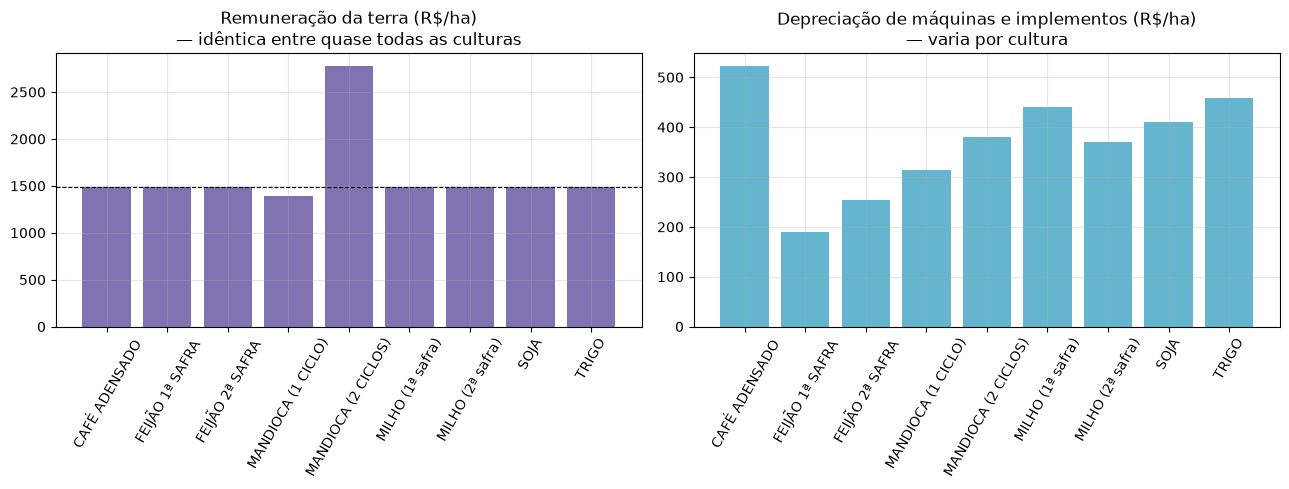

Milho 2ª safra vs. Soja:
item              depreciacao_maquinas_rs_ha  remuneracao_terra_rs_ha
cultura                                                              
MILHO (2ª safra)                      370.27                  1491.02
SOJA                                  409.78                  1491.02


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

axes[0].bar(terra_maquina.index, terra_maquina["remuneracao_terra_rs_ha"], color="#8172B2")
axes[0].set_title("Remuneração da terra (R$/ha)\n— idêntica entre quase todas as culturas")
axes[0].tick_params(axis="x", rotation=60)
axes[0].axhline(terra_maquina["remuneracao_terra_rs_ha"].mode().iloc[0], color="black", linestyle="--", linewidth=0.8)

axes[1].bar(terra_maquina.index, terra_maquina["depreciacao_maquinas_rs_ha"], color="#64B5CD")
axes[1].set_title("Depreciação de máquinas e implementos (R$/ha)\n— varia por cultura")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

destaque = terra_maquina.loc[["MILHO (2ª safra)", "SOJA"]]
print("Milho 2ª safra vs. Soja:")
print(destaque.round(2).to_string())

**Confirmado**: "Remuneração da terra" é **idêntica**, casa decimal por casa decimal, em
milho 2ª safra, soja, café, feijão e trigo (R$ 1.491,02/ha) — a única exceção é mandioca de 2
ciclos, que mostra exatamente o dobro do valor de mandioca de 1 ciclo, confirmando que é o mesmo
valor de referência anual multiplicado pelo tempo de ocupação. O DERAL não desconta nada de terra
no relatório do milho safrinha por ele suceder a soja na mesma área — cada cultura recebe o
**mesmo custo de oportunidade da terra cheio**, como se fosse a única ocupante do ano inteiro.
Somar custo fixo de soja + milho safrinha do mesmo hectare/ano **conta a terra duas vezes**.

Já a depreciação de máquinas **não se repete** — varia por cultura (370 no milho safrinha vs. 410
na soja vs. 458 no trigo), porque reflete o conjunto de operações específico de cada uma. Não há
duplicação óbvia aí.

**Implicação**: em vez de ratear o custo fixo inteiro (que mistura terra + máquina) por uma fração
assumida, faz mais sentido excluir especificamente a Renda de Fatores (que inclui a terra) —
exatamente o conceito de **Custo Operacional** (= Custo Total − Renda de Fatores). A seção seguinte
mede, com dados históricos reais (não só este único período), quanto essa exclusão representa.

## 3. Renda de Fatores como fração do Custo Total — série histórica CONAB

`custos.xlsx` só tem 5 datas recentes (2025-2026) — não dá pra construir uma série histórica. Mas o
`df_pr_long_deflacionado.csv` (pipeline `06`/`07`, descontinuado como referência de custo *absoluto*
por causa da produtividade do pacote CONAB, mas ainda com a estrutura de custo íntegra) **tem** a
separação Custo Operacional (H) / Renda de Fatores (I) / Custo Total (J) para as 6 cidades do PR,
1999-2025 — dá pra medir a proporção ano a ano.

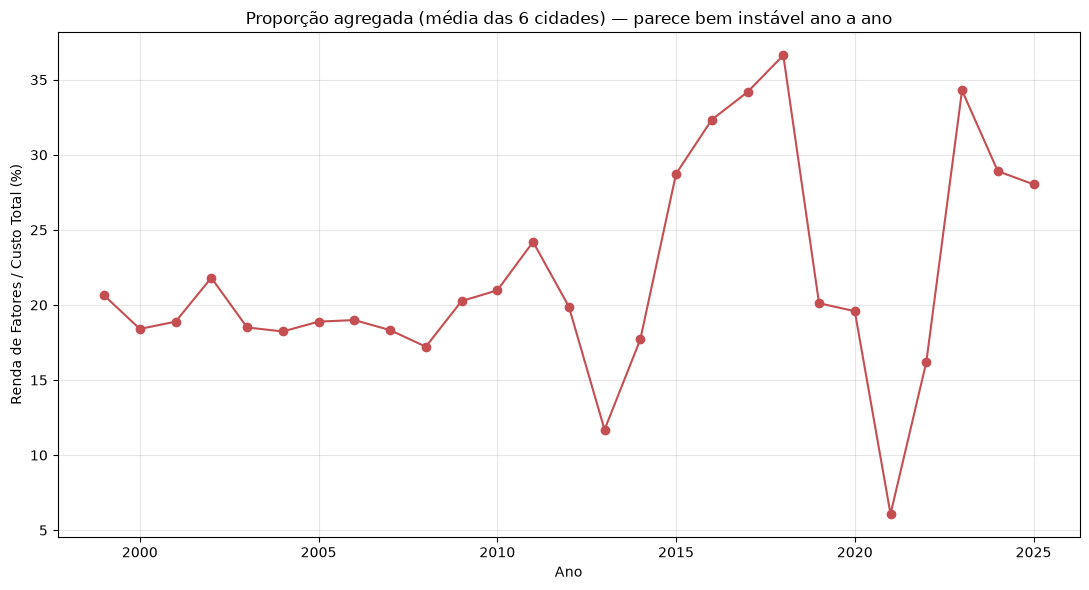

Média 1999-2025: 21.8%  desvio-padrão entre anos: 7.0%


In [5]:
df_conab = pd.read_csv("df_pr_long_deflacionado.csv")

conab_hij = df_conab[df_conab["categoria_total"].isin(
    ["Custo Operacional (H)", "Total Renda de Fatores (I)", "Custo Total (J)"]
)]

# Primeira tentativa: agregado direto por ano (média entre as 6 cidades) — este é o número que
# parecia "ruidoso" na conversa que motivou este notebook.
piv_ano = conab_hij.pivot_table(index="ano", columns="categoria_total", values="custo_rs_ha", aggfunc="mean")
piv_ano["ratio_I_sobre_J"] = piv_ano["Total Renda de Fatores (I)"] / piv_ano["Custo Total (J)"]

fig, ax = plt.subplots()
ax.plot(piv_ano.index, piv_ano["ratio_I_sobre_J"] * 100, marker="o", color=CORES["operacional_conab"])
ax.set_ylabel("Renda de Fatores / Custo Total (%)")
ax.set_xlabel("Ano")
ax.set_title("Proporção agregada (média das 6 cidades) — parece bem instável ano a ano")
plt.tight_layout()
plt.show()

print(f"Média 1999-2025: {piv_ano['ratio_I_sobre_J'].mean():.1%}  desvio-padrão entre anos: {piv_ano['ratio_I_sobre_J'].std():.1%}")

À primeira vista parece ruído demais pra confiar (desvio-padrão entre anos alto). Mas antes
de descartar, vale checar se é ruído de verdade ou um padrão real que a média entre cidades está
escondendo — quebrando por cidade dentro de cada ano.

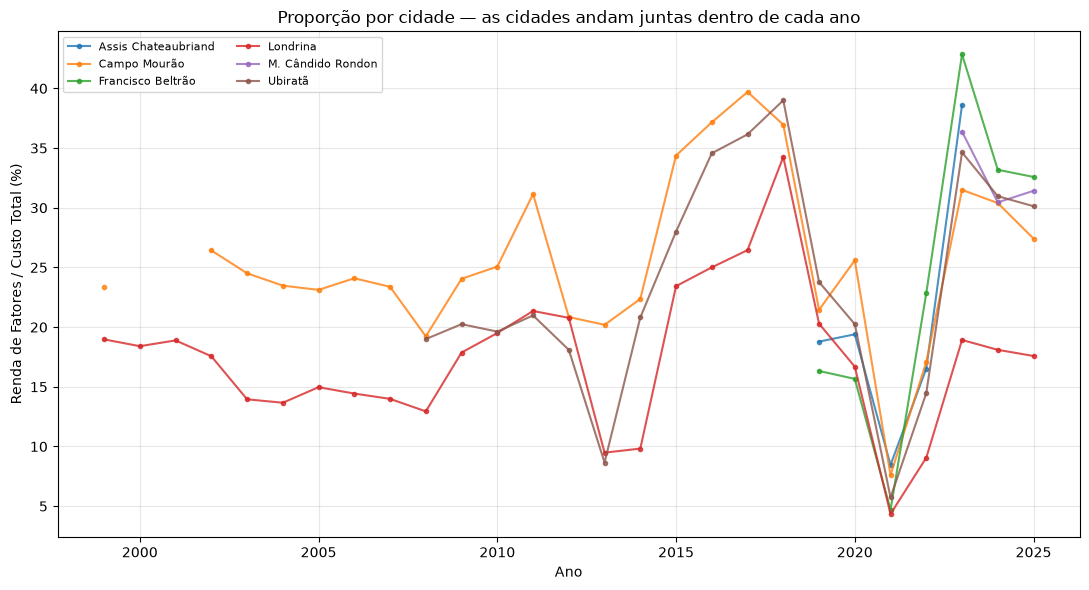

Desvio-padrão ENTRE CIDADES dentro do mesmo ano (média ao longo dos anos): 5.1%
Desvio-padrão ENTRE ANOS (série agregada): 7.0%


In [6]:
piv_cidade_ano = conab_hij.pivot_table(
    index=["cidade", "ano"], columns="categoria_total", values="custo_rs_ha", aggfunc="mean"
)
piv_cidade_ano["ratio"] = piv_cidade_ano["Total Renda de Fatores (I)"] / piv_cidade_ano["Custo Total (J)"]
ratio_por_cidade = piv_cidade_ano["ratio"].reset_index().pivot(index="ano", columns="cidade", values="ratio")

fig, ax = plt.subplots(figsize=(11, 6))
for cidade in ratio_por_cidade.columns:
    ax.plot(ratio_por_cidade.index, ratio_por_cidade[cidade] * 100, marker=".", alpha=0.8, label=cidade)
ax.set_ylabel("Renda de Fatores / Custo Total (%)")
ax.set_xlabel("Ano")
ax.set_title("Proporção por cidade — as cidades andam juntas dentro de cada ano")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

desvio_dentro_do_ano = ratio_por_cidade.std(axis=1)
print("Desvio-padrão ENTRE CIDADES dentro do mesmo ano (média ao longo dos anos):",
      f"{desvio_dentro_do_ano.mean():.1%}")
print("Desvio-padrão ENTRE ANOS (série agregada):", f"{piv_ano['ratio_I_sobre_J'].std():.1%}")

**A dispersão entre cidades no mesmo ano é menor que a dispersão entre anos** — as
cidades sobem e descem juntas (ex. 2021 caiu pra todas ao mesmo tempo, 2018 subiu pra todas), como
o gráfico acima deixa claro visualmente. Isso não parece ruído de medição — é um padrão macro real. As duas hipóteses mais prováveis: **juros** (a
"Remuneração do capital próprio" costuma ser calculada com uma taxa de referência — 2021 foi o ano
de SELIC historicamente baixa da pandemia) e **valorização da terra** (2015-2018 e 2023-2025 foram
períodos de alta no valor da terra agrícola no Paraná). Ou seja: dá pra confiar nessa série **ano a
ano**, só não dá pra resumir num número único constante ao longo de 26 anos.

Antes de fechar a série, duas validações:

In [7]:
# Validação 1: a planilha já traz uma coluna "participacao_pct" própria — se bater com o
# ratio que calculamos a partir de custo_rs_ha, aumenta a confiança de que não é artefato de parsing.
sub_I = df_conab[df_conab["categoria_total"] == "Total Renda de Fatores (I)"]
comparacao_participacao = (
    sub_I.groupby("ano")["participacao_pct"].agg(["mean", "std"]).rename(columns={"mean": "participacao_pct_media"})
)
print("participacao_pct (coluna já calculada na planilha original) por ano — note a quebra de escala a partir de 2011:")
print(comparacao_participacao.round(3).to_string())

participacao_pct (coluna já calculada na planilha original) por ano — note a quebra de escala a partir de 2011:
      participacao_pct_media     std
ano                                 
1999                   0.212   0.031
2000                   0.184     NaN
2001                   0.189     NaN
2002                   0.220   0.063
2003                   0.192   0.075
2004                   0.186   0.069
2005                   0.190   0.058
2006                   0.193   0.068
2007                   0.187   0.066
2008                   0.171   0.036
2009                   0.207   0.031
2010                   0.214   0.032
2011                  40.033  15.320
2012                  29.047   3.296
2013                  17.853  11.235
2014                  26.530  12.396
2015                  46.037  12.954
2016                  54.670  15.422
2017                  59.893  17.784
2018                  66.083   6.538
2019                  18.984  17.306
2020                  28.304   6.151


**Bug de unidade confirmado**: até 2010 `participacao_pct` bate com o nosso ratio calculado
a partir de `custo_rs_ha` (ex. 1999: 0,212 nos dois). A partir de 2011 os valores da coluna
`participacao_pct` disparam pra escala de ponto percentual (40, 66, 48...) em vez de fração — o
mesmo tipo de inconsistência de layout entre anos já documentado no `07` para outras categorias.
**Por isso não usamos essa coluna** — seguimos com o ratio calculado direto de `custo_rs_ha`
(`Total Renda de Fatores (I) / Custo Total (J)`), que não depende dela.

In [8]:
# Validação 2: cruzar com a categoria "Custo Operacional (H)" que a planilha já separa
# explicitamente — H deveria ser igual a J - I (Custo Operacional = Custo Total - Renda de Fatores).
piv_ano["custo_operacional_H_sobre_J"] = piv_ano["Custo Operacional (H)"] / piv_ano["Custo Total (J)"]
piv_ano["check_H_igual_J_menos_I"] = (
    piv_ano["Custo Operacional (H)"] - (piv_ano["Custo Total (J)"] - piv_ano["Total Renda de Fatores (I)"])
).abs()

print("Maior diferença absoluta entre H e (J - I), nos 27 anos:",
      f"R$ {piv_ano['check_H_igual_J_menos_I'].max():.2f}/ha")
print()
print("1 - (I/J) vs H/J (deveriam ser praticamente iguais):")
comp = pd.DataFrame({
    "1_menos_I_sobre_J": 1 - piv_ano["ratio_I_sobre_J"],
    "H_sobre_J": piv_ano["custo_operacional_H_sobre_J"],
})
print(comp.round(4).head(10).to_string())

Maior diferença absoluta entre H e (J - I), nos 27 anos: R$ 0.00/ha

1 - (I/J) vs H/J (deveriam ser praticamente iguais):
      1_menos_I_sobre_J  H_sobre_J
ano                               
1999             0.7936     0.7936
2000             0.8160     0.8160
2001             0.8111     0.8111
2002             0.7819     0.7819
2003             0.8150     0.8150
2004             0.8177     0.8177
2005             0.8111     0.8111
2006             0.8101     0.8101
2007             0.8167     0.8167
2008             0.8278     0.8278


As duas contas batem (diferença de centavos, arredondamento) — confirma que a categoria
`Custo Operacional (H)` já publicada na planilha é consistente com `Custo Total (J) − Renda de
Fatores (I)`, reforçando que a proporção medida é real, não um artefato do nosso cálculo.

Consolidando: a série final usada na seção 4 é a **média entre cidades disponíveis, por ano** —
não a média constante do período inteiro.

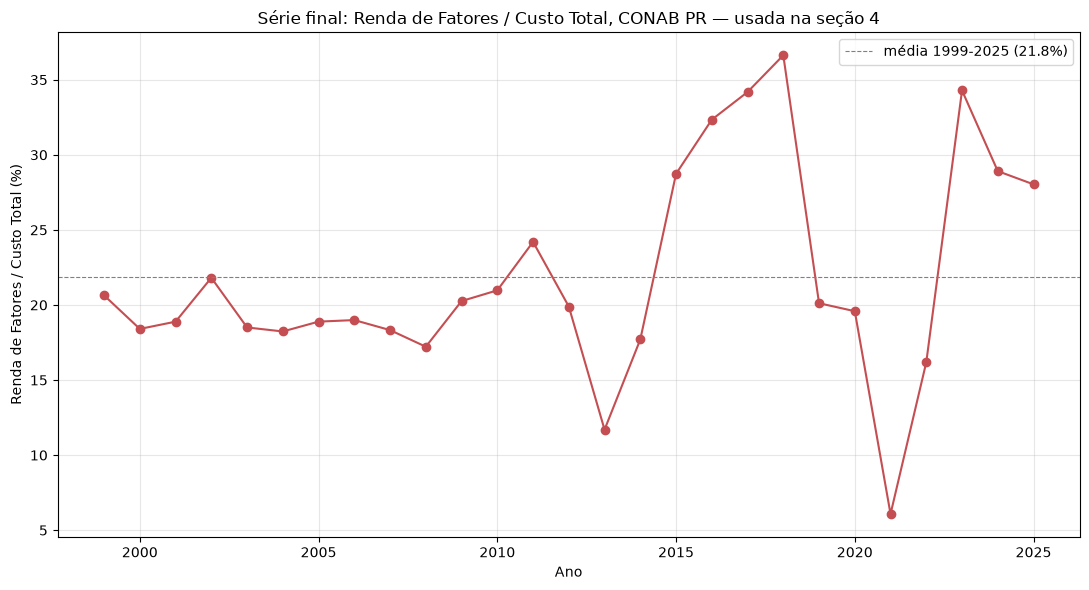

Média 1999-2025: 21.8%
Média 2019-2025 (mesma janela usada no 09 para preço/custo): 21.9%
Mínimo: 6.1% (ano 2021)
Máximo: 36.6% (ano 2018)


In [9]:
ratio_renda_fatores_conab = piv_ano["ratio_I_sobre_J"].rename("ratio_renda_fatores")

fig, ax = plt.subplots()
ax.plot(ratio_renda_fatores_conab.index, ratio_renda_fatores_conab.values * 100,
        marker="o", color=CORES["operacional_conab"])
ax.axhline(ratio_renda_fatores_conab.mean() * 100, color="gray", linestyle="--", linewidth=0.8,
           label=f"média 1999-2025 ({ratio_renda_fatores_conab.mean():.1%})")
ax.set_ylabel("Renda de Fatores / Custo Total (%)")
ax.set_xlabel("Ano")
ax.set_title("Série final: Renda de Fatores / Custo Total, CONAB PR — usada na seção 4")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Média 1999-2025: {ratio_renda_fatores_conab.mean():.1%}")
print(f"Média 2019-2025 (mesma janela usada no 09 para preço/custo): {ratio_renda_fatores_conab.loc[2019:2025].mean():.1%}")
print(f"Mínimo: {ratio_renda_fatores_conab.min():.1%} (ano {ratio_renda_fatores_conab.idxmin()})")
print(f"Máximo: {ratio_renda_fatores_conab.max():.1%} (ano {ratio_renda_fatores_conab.idxmax()})")

## 4. Construindo o cenário "Custo Operacional (CONAB)" para o milho safrinha DERAL

Aplicamos a série de proporções acima sobre o custo **DERAL** (não o CONAB — a fonte de custo
absoluto continua sendo a mesma do `09`, só a *proporção* de quanto é Renda de Fatores vem do
CONAB, por não existir essa quebra na série DERAL):

```
custo_operacional_real[ano] = custo_rs_ha_total_real[ano] × (1 − ratio_renda_fatores_conab[ano])
custo_fixo_operacional_real[ano] = custo_operacional_real[ano] − custo_rs_ha_variavel_real[ano]
```

`custo_fixo_operacional_real` substitui `custo_fixo_real × fator_rateio` das seções 6.1/6.2 do
`09` — em vez de descontar uma fração igual de todo o custo fixo (terra **e** máquina juntos), essa
versão desconta só a fatia que os dados confirmam ser especificamente Renda de Fatores (que inclui
a terra duplicada) e mantém o resto (depreciação de máquina, mão de obra permanente etc., que **não**
se repete entre culturas, seção 2) mais próximo do valor cheio.

**Limite dos dados DERAL 1999-2024**: a série CONAB cobre 1999-2025, mas cobertura de cidades varia
por ano (nem todas as 6 cidades têm dado em todos os anos, ver seção 3) — usamos a média disponível
em cada ano de qualquer forma, e o merge abaixo já se limita aos anos em comum com a série DERAL.

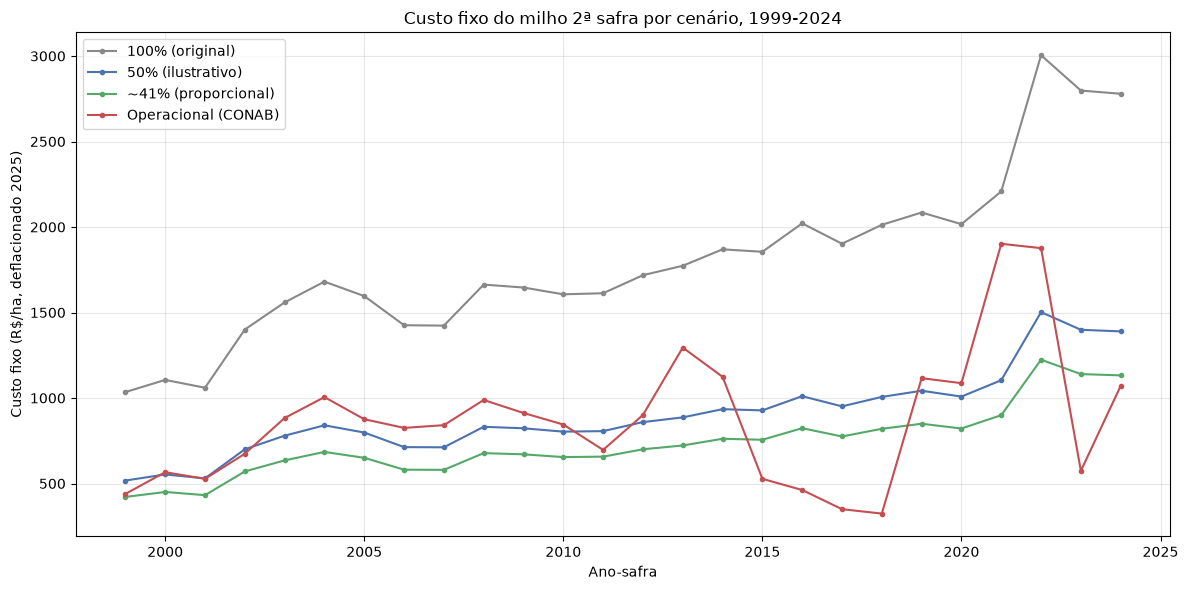

,100% (original),50% (ilustrativo),~41% (proporcional),Operacional (CONAB)
ano,,,,
2015,1855.1,927.6,755.8,527.4
2016,2021.3,1010.7,823.5,462.0
2017,1902.2,951.1,775.0,349.8
2018,2012.7,1006.4,820.0,324.1
2019,2084.8,1042.4,849.4,1116.0
2020,2016.7,1008.3,821.6,1086.7
2021,2207.9,1103.9,899.5,1901.8
2022,3004.4,1502.2,1224.0,1876.3
2023,2798.0,1399.0,1139.9,574.1


In [10]:
custo_deral_idx = custo_deral.set_index("ano")

ratio_disponivel = ratio_renda_fatores_conab.reindex(custo_deral_idx.index)
if ratio_disponivel.isna().any():
    anos_faltando = ratio_disponivel[ratio_disponivel.isna()].index.tolist()
    print(f"Anos DERAL sem cobertura direta na série CONAB: {anos_faltando} — preenchidos por "
          f"interpolação linear (vizinhos mais próximos).")
    ratio_disponivel = ratio_disponivel.interpolate(limit_direction="both")

custo_operacional_real = custo_deral_idx["custo_rs_ha_total_real"] * (1 - ratio_disponivel)
custo_fixo_operacional_real = custo_operacional_real - custo_deral_idx["custo_rs_ha_variavel_real"]
custo_fixo_operacional_real.name = "custo_fixo_operacional_real"

# Exporta a série completa (real e nominal) — usada como fonte de custo do cenário Operacional
# (CONAB) em qualquer notebook posterior que precise dela (ex. gráficos de custo/preço do 12b),
# no mesmo formato de colunas de custo_deral_milho_safrinha.csv, só que com o fixo já descontado.
custo_deral_operacional_conab = pd.DataFrame({
    "ano": custo_deral_idx.index,
    "ratio_renda_fatores_conab": ratio_disponivel.values,
    "custo_fixo_operacional_real": custo_fixo_operacional_real.values,
    "custo_rs_ha_variavel_real": custo_deral_idx["custo_rs_ha_variavel_real"].values,
    "custo_operacional_total_real": custo_operacional_real.values,
    "fator_deflator": custo_deral_idx["fator_deflator"].values,
})
custo_deral_operacional_conab["custo_fixo_operacional_nominal"] = (
    custo_deral_operacional_conab["custo_fixo_operacional_real"] / custo_deral_operacional_conab["fator_deflator"]
)
custo_deral_operacional_conab["custo_operacional_total_nominal"] = (
    custo_deral_operacional_conab["custo_operacional_total_real"] / custo_deral_operacional_conab["fator_deflator"]
)
custo_deral_operacional_conab["custo_rs_ha_variavel_nominal"] = custo_deral_idx["custo_rs_ha_variavel_nominal"].values
custo_deral_operacional_conab.to_csv("custo_deral_operacional_conab.csv", index=False, encoding="utf-8-sig")

CICLO_SOJA_DIAS = 160
CICLO_MILHO_SAFRINHA_DIAS = 110
FATOR_RATEIO_PROPORCIONAL = CICLO_MILHO_SAFRINHA_DIAS / (CICLO_SOJA_DIAS + CICLO_MILHO_SAFRINHA_DIAS)

comparacao_custo_fixo = pd.DataFrame({
    "100% (original)": custo_deral_idx["custo_fixo_real"],
    "50% (ilustrativo)": custo_deral_idx["custo_fixo_real"] * 0.5,
    f"~{FATOR_RATEIO_PROPORCIONAL:.0%} (proporcional)": custo_deral_idx["custo_fixo_real"] * FATOR_RATEIO_PROPORCIONAL,
    "Operacional (CONAB)": custo_fixo_operacional_real,
})

fig, ax = plt.subplots(figsize=(12, 6))
for col, cor in zip(comparacao_custo_fixo.columns, [CORES["100pct"], CORES["rateio50"], CORES["proporcional"], CORES["operacional_conab"]]):
    ax.plot(comparacao_custo_fixo.index, comparacao_custo_fixo[col], marker=".", label=col, color=cor)
ax.set_ylabel("Custo fixo (R$/ha, deflacionado 2025)")
ax.set_xlabel("Ano-safra")
ax.set_title("Custo fixo do milho 2ª safra por cenário, 1999-2024")
ax.legend()
plt.tight_layout()
plt.show()

comparacao_custo_fixo.round(1).tail(10)

O cenário Operacional (CONAB) não é uma fração fixa do "100% original" — ele **acompanha a
forma da série de proporção CONAB** (mais baixo relativamente em 2021, mais alto em 2018/2023-24),
diferente dos cenários 50%/proporcional que são sempre a mesma fração do 100% em qualquer ano.

## 5. Risco econômico — o cenário Custo Operacional (CONAB) ao lado dos outros 3

Mesma lógica de `calcular_risco_economico` do `09` (seção 6): para cada (município, data de
semeadura), cruza a produtividade prevista de cada ano com o custo e o preço reais **daquele
mesmo ano**, calcula a margem, e classifica por tercil de margem média nas 300 combinações.

In [11]:
ANOS_EM_COMUM = sorted(set(previsoes["ano"]) & set(custo_deral["ano"]) & set(preco_ref_full["ano"]))
print(f"Anos em comum: {len(ANOS_EM_COMUM)} ({min(ANOS_EM_COMUM)}-{max(ANOS_EM_COMUM)})")

preco_idx = preco_ref_full.set_index("ano")["preco_rs_60kg_real"]
custo_var_kg_idx = custo_deral_idx["custo_var_kg_real"]


def calcular_risco_economico(custo_fixo_por_ano, rotulo):
    base = previsoes[previsoes["ano"].isin(ANOS_EM_COMUM)].copy()
    base["custo_fixo"] = base["ano"].map(custo_fixo_por_ano)
    base["custo_var_kg"] = base["ano"].map(custo_var_kg_idx)
    base["preco_60kg"] = base["ano"].map(preco_idx)

    base["custo_ajustado_rs_ha"] = base["custo_fixo"] + base["custo_var_kg"] * base["produtividade_prevista_kg_ha"]
    base["receita_rs_ha"] = (base["preco_60kg"] / 60) * base["produtividade_prevista_kg_ha"]
    base["margem_rs_ha"] = base["receita_rs_ha"] - base["custo_ajustado_rs_ha"]
    base["cobre_custo"] = base["margem_rs_ha"] >= 0

    risco = base.groupby(["municipio", "data_semeadura"]).agg(
        n_anos=("ano", "count"),
        pct_anos_cobre_custo=("cobre_custo", "mean"),
        margem_media_rs_ha=("margem_rs_ha", "mean"),
    ).reset_index()
    risco["pct_anos_cobre_custo"] = (risco["pct_anos_cobre_custo"] * 100).round(1)
    risco["risco_economico"] = pd.qcut(
        risco["margem_media_rs_ha"], q=3, labels=["Menos viável", "Viabilidade intermediária", "Mais viável"],
    )

    print(f"\n[{rotulo}] distribuição de risco_economico:")
    print(risco["risco_economico"].value_counts())
    return risco


risco_economico_operacional = calcular_risco_economico(custo_fixo_operacional_real, "Custo Operacional (CONAB)")
risco_economico_operacional.to_csv("risco_economico_oeste_pr_operacional_conab.csv", index=False, encoding="utf-8-sig")
risco_economico_operacional.sort_values("margem_media_rs_ha", ascending=False).head(10)

Anos em comum: 26 (1999-2024)

[Custo Operacional (CONAB)] distribuição de risco_economico:
risco_economico
Menos viável                 100
Viabilidade intermediária    100
Mais viável                  100
Name: count, dtype: int64


,municipio,data_semeadura,n_anos,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico
52,Catanduvas,25/02/,26,50.0,106.973281,Mais viável
112,Ibema,25/02/,26,50.0,106.340486,Mais viável
74,Diamante do Sul,15/02/,26,50.0,104.339435,Mais viável
46,Cascavel,25/02/,26,50.0,104.052241,Mais viável
100,Guaraniaçu,25/02/,26,50.0,103.836074,Mais viável
49,Catanduvas,05/03/,26,50.0,101.053207,Mais viável
34,Campo Bonito,25/02/,26,50.0,100.173011,Mais viável
76,Diamante do Sul,25/02/,26,50.0,99.881040,Mais viável
50,Catanduvas,15/02/,26,50.0,99.518443,Mais viável
98,Guaraniaçu,15/02/,26,50.0,99.055416,Mais viável


Município×data que mudam de classificação de risco econômico no cenário Operacional (CONAB): 0/300

            cenario  margem_media_rs_ha  pct_anos_cobre_custo_media combinacoes_margem_positiva
    100% (original)              -897.9                         5.8                       0/300
  50% (ilustrativo)                 3.2                        47.7                     172/300
~41% (proporcional)               170.1                        55.3                     300/300
Operacional (CONAB)                31.7                        48.4                     219/300


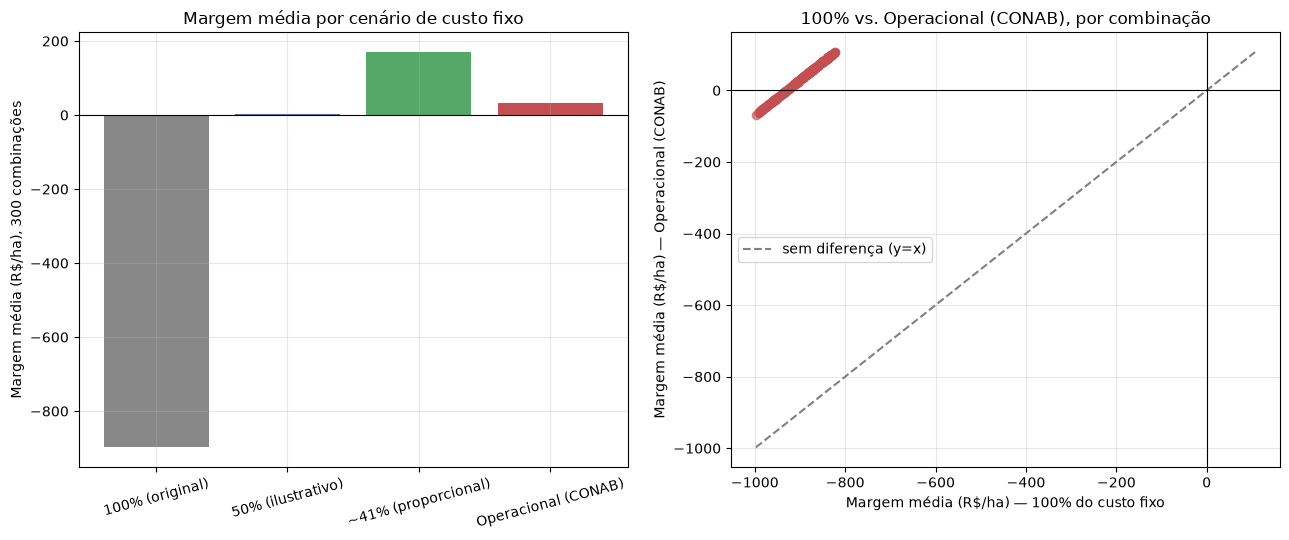

In [12]:
CENARIOS = {
    "100% (original)": risco_economico_100pct,
    "50% (ilustrativo)": risco_economico_rateio50,
    f"~{FATOR_RATEIO_PROPORCIONAL:.0%} (proporcional)": risco_economico_proporcional,
    "Operacional (CONAB)": risco_economico_operacional,
}

resumo_cenarios = pd.DataFrame([
    {
        "cenario": nome,
        "margem_media_rs_ha": df["margem_media_rs_ha"].mean(),
        "pct_anos_cobre_custo_media": df["pct_anos_cobre_custo"].mean(),
        "combinacoes_margem_positiva": int((df["margem_media_rs_ha"] >= 0).sum()),
    }
    for nome, df in CENARIOS.items()
])
resumo_cenarios["combinacoes_margem_positiva"] = (
    resumo_cenarios["combinacoes_margem_positiva"].astype(str) + "/" + str(len(risco_economico_100pct))
)

comparacao_operacional = risco_economico_100pct.merge(
    risco_economico_operacional, on=["municipio", "data_semeadura"], suffixes=("_100pct", "_operacional"),
)
n_mudou = (
    comparacao_operacional["risco_economico_100pct"] != comparacao_operacional["risco_economico_operacional"]
).sum()
print(f"Município×data que mudam de classificação de risco econômico no cenário Operacional (CONAB): "
      f"{n_mudou}/{len(comparacao_operacional)}")
print()
print(resumo_cenarios.round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

cores_barras = [CORES["100pct"], CORES["rateio50"], CORES["proporcional"], CORES["operacional_conab"]]
axes[0].bar(resumo_cenarios["cenario"], resumo_cenarios["margem_media_rs_ha"], color=cores_barras)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Margem média (R$/ha), 300 combinações")
axes[0].set_title("Margem média por cenário de custo fixo")
axes[0].tick_params(axis="x", rotation=15)

axes[1].scatter(
    comparacao_operacional["margem_media_rs_ha_100pct"],
    comparacao_operacional["margem_media_rs_ha_operacional"],
    alpha=0.6, color=CORES["operacional_conab"],
)
lim = [
    min(comparacao_operacional["margem_media_rs_ha_100pct"].min(), comparacao_operacional["margem_media_rs_ha_operacional"].min()),
    max(comparacao_operacional["margem_media_rs_ha_100pct"].max(), comparacao_operacional["margem_media_rs_ha_operacional"].max()),
]
axes[1].plot(lim, lim, linestyle="--", color="gray", label="sem diferença (y=x)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Margem média (R$/ha) — 100% do custo fixo")
axes[1].set_ylabel("Margem média (R$/ha) — Operacional (CONAB)")
axes[1].set_title("100% vs. Operacional (CONAB), por combinação")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Matriz risco climático × viabilidade econômica — cenário Operacional (CONAB)

Mesma lógica da seção 7 do `09`: cruza o risco climático (ZARC/ISNA, eixo independente, não muda
entre cenários de custo) com a viabilidade econômica do cenário Operacional (CONAB), para indicar
a melhor data de semeadura por município.

In [13]:
ORDEM_CLIMA = {"Risco climático 20%": 0, "Risco climático 30%": 1, "Risco climático 40%": 2, "Inapto (risco > 40%)": 3}
ORDEM_ECONOMICO = {"Mais viável": 0, "Viabilidade intermediária": 1, "Menos viável": 2}

matriz_operacional = risco_climatico.merge(
    risco_economico_operacional[["municipio", "data_semeadura", "pct_anos_cobre_custo", "margem_media_rs_ha", "risco_economico"]],
    on=["municipio", "data_semeadura"],
)

# Margem dos 4 cenários lado a lado, como referência (mesma lógica do 09, célula da seção 7).
for nome_col, df_cenario in [
    ("margem_media_rs_ha_100pct", risco_economico_100pct),
    ("margem_media_rs_ha_rateio50", risco_economico_rateio50),
    ("margem_media_rs_ha_rateio_proporcional", risco_economico_proporcional),
]:
    matriz_operacional = matriz_operacional.merge(
        df_cenario[["municipio", "data_semeadura", "margem_media_rs_ha"]].rename(columns={"margem_media_rs_ha": nome_col}),
        on=["municipio", "data_semeadura"],
    )
matriz_operacional = matriz_operacional.rename(columns={"margem_media_rs_ha": "margem_media_rs_ha_operacional_conab"})

matriz_operacional["score_clima"] = matriz_operacional["risco_climatico"].map(ORDEM_CLIMA).astype(int)
matriz_operacional["score_economico"] = matriz_operacional["risco_economico"].map(ORDEM_ECONOMICO).astype(int)
matriz_operacional["score_combinado"] = matriz_operacional["score_clima"] + matriz_operacional["score_economico"]

matriz_operacional.to_csv("matriz_risco_climatico_economico_oeste_pr_operacional_conab.csv", index=False, encoding="utf-8-sig")

print("Combinações risco climático × viabilidade econômica relativa (cenário Operacional CONAB):")
print(pd.crosstab(matriz_operacional["risco_climatico"], matriz_operacional["risco_economico"]))

Combinações risco climático × viabilidade econômica relativa (cenário Operacional CONAB):
risco_economico       Menos viável  Viabilidade intermediária  Mais viável
risco_climatico                                                           
Inapto (risco > 40%)            86                         64           31
Risco climático 30%              7                         19           31
Risco climático 40%              7                         17           38


In [14]:
melhor_data_operacional = (
    matriz_operacional.sort_values(["municipio", "score_combinado", "isna_medio"], ascending=[True, True, False])
    .groupby("municipio")
    .first()
    .reset_index()[[
        "municipio", "data_semeadura", "risco_climatico", "isna_medio", "risco_economico", "pct_anos_cobre_custo",
        "margem_media_rs_ha_100pct", "margem_media_rs_ha_rateio50", "margem_media_rs_ha_rateio_proporcional",
        "margem_media_rs_ha_operacional_conab",
    ]]
)
melhor_data_operacional.to_csv("melhor_data_semeadura_por_municipio_operacional_conab.csv", index=False, encoding="utf-8-sig")

# Comparação com a recomendação original (100%, já exportada pelo 09) — quantos municípios mudam
# de melhor data recomendada ao trocar de cenário de custo fixo.
melhor_data_100pct = pd.read_csv("melhor_data_semeadura_por_municipio.csv")
comparacao_melhor_data = melhor_data_100pct[["municipio", "data_semeadura"]].merge(
    melhor_data_operacional[["municipio", "data_semeadura"]], on="municipio", suffixes=("_100pct", "_operacional_conab"),
)
n_mudou_data = (comparacao_melhor_data["data_semeadura_100pct"] != comparacao_melhor_data["data_semeadura_operacional_conab"]).sum()
print(f"Municípios cuja melhor data de semeadura recomendada muda entre 100% e Operacional (CONAB): "
      f"{n_mudou_data}/{len(comparacao_melhor_data)}")

melhor_data_operacional.sort_values("isna_medio", ascending=False).head(15)

Municípios cuja melhor data de semeadura recomendada muda entre 100% e Operacional (CONAB): 0/50


,municipio,data_semeadura,risco_climatico,isna_medio,risco_economico,pct_anos_cobre_custo,margem_media_rs_ha_100pct,margem_media_rs_ha_rateio50,margem_media_rs_ha_rateio_proporcional,margem_media_rs_ha_operacional_conab
12,Diamante do Sul,15/02/,Risco climático 30%,0.773392,Mais viável,50.0,-825.252747,75.844359,242.714193,104.339435
16,Guaraniaçu,15/02/,Risco climático 30%,0.769103,Mais viável,50.0,-830.536766,70.560339,237.430173,99.055416
8,Catanduvas,15/02/,Risco climático 30%,0.767835,Mais viável,50.0,-830.073739,71.023366,237.893201,99.518443
18,Ibema,15/02/,Risco climático 30%,0.763993,Mais viável,50.0,-833.608041,67.489065,234.358899,95.984141
47,Três Barras do Paraná,05/02/,Risco climático 30%,0.763884,Mais viável,50.0,-871.346753,29.750352,196.620186,58.245429
3,Braganey,15/02/,Risco climático 30%,0.763424,Mais viável,50.0,-839.273789,61.823316,228.693150,90.318393
5,Campo Bonito,15/02/,Risco climático 30%,0.763090,Mais viável,50.0,-837.723418,63.373687,230.243521,91.868764
7,Cascavel,15/02/,Risco climático 30%,0.758423,Mais viável,50.0,-838.576525,62.520581,229.390415,91.015657
2,Boa Vista da Aparecida,15/02/,Risco climático 30%,0.747241,Mais viável,50.0,-837.298920,63.798185,230.668019,92.293262
23,Lindoeste,15/02/,Risco climático 30%,0.742594,Mais viável,50.0,-871.784778,29.312327,196.182162,57.807404


### Mapa de calor — risco combinado por município × data de semeadura (cenário Operacional CONAB)

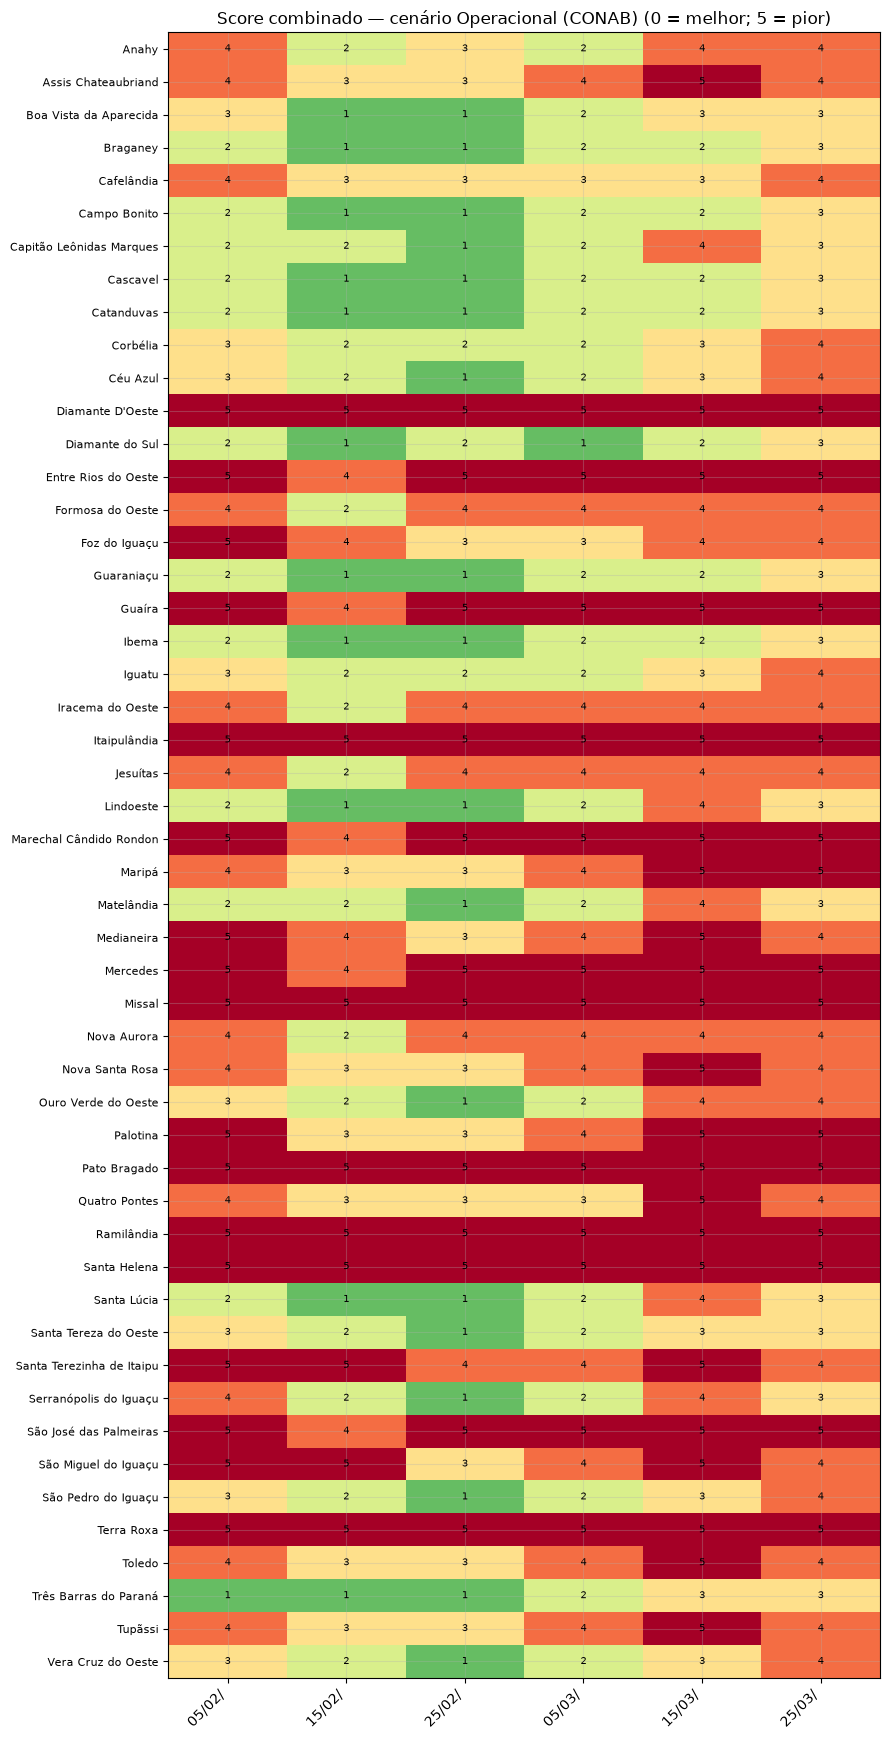

In [15]:
pivot_score = matriz_operacional.pivot(index="municipio", columns="data_semeadura", values="score_combinado")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_score))))
im = ax.imshow(pivot_score, cmap="RdYlGn_r", vmin=0, vmax=5, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_score.index)))
ax.set_yticklabels(pivot_score.index, fontsize=8)
for i in range(pivot_score.shape[0]):
    for j in range(pivot_score.shape[1]):
        v = pivot_score.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("Score combinado — cenário Operacional (CONAB) (0 = melhor; 5 = pior)")
plt.tight_layout()
plt.show()

## 7. Qual cenário usar?

| Cenário | Base do desconto | Vantagem | Limitação |
|---|---|---|---|
| 100% (original) | Nenhum desconto | Simples, conservador | Ignora que a terra é reutilizada pela soja no mesmo ano |
| 50% (ilustrativo) | Metade do custo fixo inteiro | Fácil de comunicar | Sem fonte que justifique 50% especificamente; desconta terra **e** máquina igualmente, mas só a terra se repete de fato (seção 2) |
| ~41% (proporcional) | Dias de ocupação soja/milho | Mais defensável que 50% | Mesma limitação: desconta máquina junto com terra, sem necessidade |
| **Operacional (CONAB)** | Proporção real de Renda de Fatores no Custo Total, medida ano a ano (seções 2-3) | Desconta só o que os dados confirmam que se duplica (terra), mantém a máquina praticamente intacta; varia ano a ano em vez de fração fixa | Proporção vem do pacote CONAB "Alta Tecnologia", não do próprio pacote DERAL milho safrinha — ver limitações abaixo |

O cenário Operacional (CONAB) é o mais bem fundamentado nos dados que temos disponíveis — não
elimina a necessidade de julgamento (a proporção vem de uma fonte diferente da fonte de custo
absoluto), mas troca "quanto da terra cabe a cada cultura?" (pergunta sem resposta direta nos
dados) por "quanto do custo total é retorno imputado de capital/terra, e não desembolso?" (pergunta
que os dados respondem diretamente, ano a ano).

**Mesmo padrão dos cenários 50%/proporcional do `09`**: em termos absolutos o efeito é grande (ver
seção 5 — a margem média salta de -R$898/ha no cenário 100% para +R$32/ha no Operacional CONAB), mas
a classificação **relativa** (tercil, e por consequência a melhor data recomendada por município) não
muda em nenhuma combinação (0/300 na seção 5, 0/50 municípios na seção 6). Isso reforça a mesma
conclusão do `09`: qualquer desconto de custo fixo aplicado de forma relativamente uniforme por ano
entre as 300 combinações muda a leitura de "o milho safrinha se paga sozinho?" (absoluta), mas não
"qual município/data é relativamente melhor que outro?" — o que segue sendo decidido pelo cenário
100% nas seções 7-10 do `09`/`10`. A diferença do cenário Operacional (CONAB) em relação aos outros
2 está em *quanto* de custo fixo é descontado a cada ano (variável, não uma fração fixa), não em
mudar essa conclusão sobre ranking relativo.

## 8. Limitações a considerar

- **A proporção Renda de Fatores/Custo Total vem do pacote CONAB "Agricultura Empresarial — Alta
  Tecnologia"**, não do próprio pacote DERAL "Milho Safrinha" (mais modesto, ~60-80 sc/ha vs.
  ~104 sc/ha do CONAB — ver `09`, seção 6) — um pacote de maior insumo tem custo variável
  proporcionalmente maior, o que dilui o peso relativo da Renda de Fatores no total. A proporção
  medida aqui (≈22% em média) pode estar levemente subestimada em relação à proporção real do
  pacote DERAL (o snapshot único do `custos.xlsx`, seção 2, sugeriu ≈29% pro milho 2ª safra em
  2026-05) — não temos como confirmar sem um detalhamento por item na própria série histórica
  DERAL, que não existe.
- **Cobertura de cidades desigual por ano** na série CONAB (nem todas as 6 cidades do PR têm dado
  em todo ano 1999-2025 — ver seção 3) — a proporção de cada ano é a média das cidades disponíveis
  naquele ano, não sempre as mesmas 6.
- **Anos DERAL sem correspondência direta na série CONAB** (se houver) foram preenchidos por
  interpolação linear entre os anos vizinhos — ver aviso impresso na seção 4, célula de construção
  do cenário.
- **A proporção assume que o mecanismo de cálculo da Renda de Fatores (juros de referência,
  valorização da terra) é o mesmo entre o pacote CONAB e o pacote DERAL** — plausível (ambos usam
  metodologia de custo de produção agropecuário padrão no Brasil), mas não confirmado item a item.
- **Risco climático (ZARC/ISNA) não muda entre cenários de custo** — é o mesmo eixo já calculado
  no `09`, seção 5; só o eixo econômico varia neste notebook.
- Demais limitações (classificação relativa por tercis, 26 anos em comum 1999-2024, eixos
  calculados de forma independente) são as mesmas do `09`, seção 8 — não repetidas aqui.